# 共享单车小时级需求预测

目标：使用 `hour.csv` 预测某个小时的共享单车总租赁量 `cnt`。

与日级模型不同，这里增加了 `hr`（小时）特征；`casual` 与 `registered` 不作为特征，因为两者相加正好等于目标 `cnt`，使用它们会造成数据泄漏。

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

sns.set_theme(style='whitegrid')

data_path = Path('../data/hour.csv')
if not data_path.exists():
    raise FileNotFoundError('找不到 hour.csv。请确认在 notebooks 文件夹中打开此 Notebook。')

df_hour = pd.read_csv(data_path, parse_dates=['dteday'])
df_hour.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


## 1. 了解小时级数据

先确认样本量、字段类型和缺失值。每一行代表某一天的某一个小时。

In [4]:
print(f'数据形状：{df_hour.shape}')
display(df_hour.info())
display(df_hour.isna().sum().to_frame('缺失值数量').T)
df_hour[['dteday', 'hr', 'cnt']].describe()

数据形状：(17379, 17)
<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[us]
 2   season      17379 non-null  int64         
 3   yr          17379 non-null  int64         
 4   mnth        17379 non-null  int64         
 5   hr          17379 non-null  int64         
 6   holiday     17379 non-null  int64         
 7   weekday     17379 non-null  int64         
 8   workingday  17379 non-null  int64         
 9   weathersit  17379 non-null  int64         
 10  temp        17379 non-null  float64       
 11  atemp       17379 non-null  float64       
 12  hum         17379 non-null  float64       
 13  windspeed   17379 non-null  float64       
 14  casual      17379 non-null  int64         
 15  registered  17379 non-null  int64         
 16  cnt         1737

None

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
缺失值数量,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


,dteday,hr,cnt
count,17379,17379.000000,17379.000000
mean,2012-01-02 04:08:34.552045,11.546752,189.463088
min,2011-01-01 00:00:00,0.000000,1.000000
25%,2011-07-04 00:00:00,6.000000,40.000000
50%,2012-01-02 00:00:00,12.000000,142.000000
75%,2012-07-02 00:00:00,18.000000,281.000000
max,2012-12-31 00:00:00,23.000000,977.000000
std,NaN,6.914405,181.387599


## 2. 探索不同时段的需求

观察一天中不同小时的平均租赁量，通常可看到早晚通勤高峰。

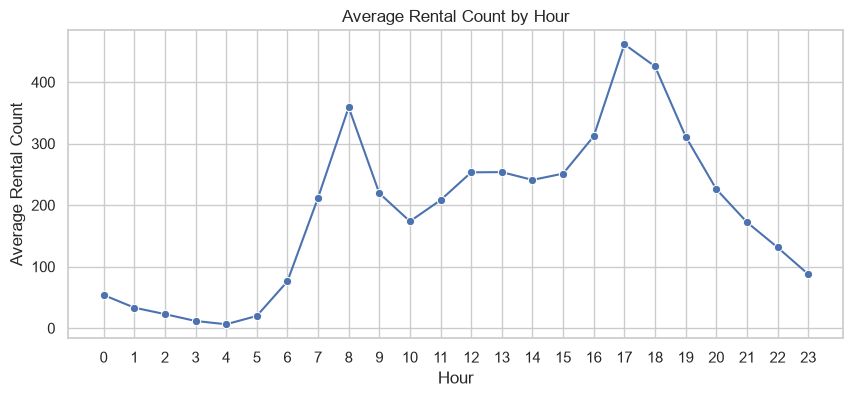

,hr,cnt
17,17,461.452055
18,18,425.510989
8,8,359.011004
16,16,311.983562
19,19,311.523352


In [5]:
hourly_mean = df_hour.groupby('hr', as_index=False)['cnt'].mean()
plt.figure(figsize=(10, 4))
sns.lineplot(data=hourly_mean, x='hr', y='cnt', marker='o')
plt.xticks(range(24))
plt.title('Average Rental Count by Hour')
plt.xlabel('Hour')
plt.ylabel('Average Rental Count')
plt.show()

hourly_mean.sort_values('cnt', ascending=False).head(5)

## 3. 按时间划分训练集和测试集

不能随机打乱数据。前 80% 的历史小时用于训练，后 20% 用于测试，模拟“用过去预测未来”。

In [6]:
FEATURES_HOURLY = [
    'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday',
    'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
]
TARGET = 'cnt'

df_hour = df_hour.sort_values(['dteday', 'hr']).reset_index(drop=True)
split_index = int(len(df_hour) * 0.8)
train = df_hour.iloc[:split_index]
test = df_hour.iloc[split_index:]

X_train, y_train = train[FEATURES_HOURLY], train[TARGET]
X_test, y_test = test[FEATURES_HOURLY], test[TARGET]

print(f'训练集：{X_train.shape[0]} 条，时间范围：{train.dteday.min().date()} 至 {train.dteday.max().date()}')
print(f'测试集：{X_test.shape[0]} 条，时间范围：{test.dteday.min().date()} 至 {test.dteday.max().date()}')

训练集：13903 条，时间范围：2011-01-01 至 2012-08-07
测试集：3476 条，时间范围：2012-08-07 至 2012-12-31


## 4. 建立基线模型并比较

先用线性回归作为基线，再使用随机森林。评价指标仍为 MAE、RMSE 和 R²。

In [7]:
def evaluate_model(name, model):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    return {
        '模型': name,
        'MAE': mean_absolute_error(y_test, pred),
        'RMSE': root_mean_squared_error(y_test, pred),
        'R²': r2_score(y_test, pred),
    }, pred

linear_result, linear_pred = evaluate_model('线性回归', LinearRegression())
rf_result, rf_pred = evaluate_model(
    '随机森林（基线）',
    RandomForestRegressor(n_estimators=150, random_state=42, n_jobs=-1),
)

results = pd.DataFrame([linear_result, rf_result]).set_index('模型')
results.round(3)

,MAE,RMSE,R²
模型,,,
线性回归,138.292,183.278,0.309
随机森林（基线）,44.992,69.653,0.900


## 5. 查看随机森林误差与特征重要性

误差图用来发现模型在哪些时段预测偏差较大；特征重要性描述模型在整体训练中最常使用哪些特征，不等于因果关系。

,dteday,hr,cnt,prediction,absolute_error
13903,2012-08-07,12,283,281.420000,1.580000
13904,2012-08-07,13,253,277.573333,24.573333
13905,2012-08-07,14,261,281.080000,20.080000
13906,2012-08-07,15,306,275.153333,30.846667
13907,2012-08-07,16,445,318.373333,126.626667


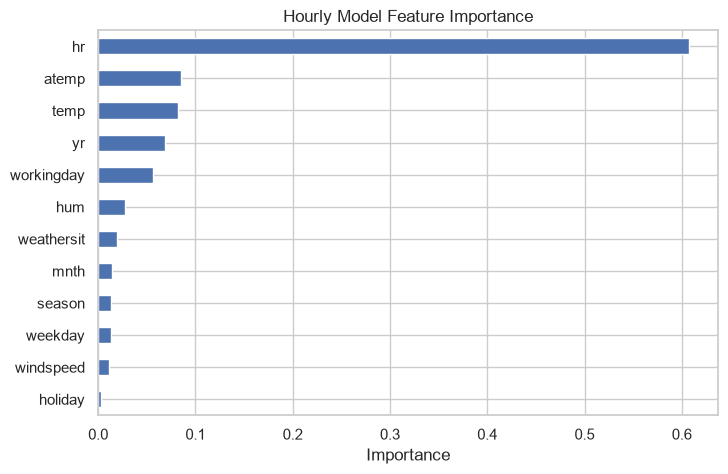

In [8]:
comparison = test[['dteday', 'hr', 'cnt']].copy()
comparison['prediction'] = rf_pred
comparison['absolute_error'] = (comparison['cnt'] - comparison['prediction']).abs()
display(comparison.head())

# 重新训练同配置模型，方便取得特征重要性。
rf_model = RandomForestRegressor(n_estimators=150, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
importance = pd.Series(rf_model.feature_importances_, index=FEATURES_HOURLY).sort_values()
importance.plot.barh(figsize=(8, 5), title='Hourly Model Feature Importance')
plt.xlabel('Importance')
plt.show()

## 6. 用时间序列交叉验证调参

调参只在训练集上完成。`TimeSeriesSplit` 始终用更早的数据训练、用更晚的数据验证，避免把未来信息泄漏给过去。

本次尝试 10 组参数组合。`n_jobs=1` 是为了避免 Windows 中文用户名下多进程可能出现的编码问题；运行大约需要几分钟。

In [9]:
param_distributions = {
    'n_estimators': [100, 150, 200],
    'max_depth': [10, 14, 18, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [0.6, 0.8, 1.0],
}

time_cv = TimeSeriesSplit(n_splits=3)
search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=1),
    param_distributions=param_distributions,
    n_iter=10,
    scoring='neg_mean_absolute_error',
    cv=time_cv,
    random_state=42,
    n_jobs=1,
    verbose=1,
)

search.fit(X_train, y_train)
search.best_params_

Fitting 3 folds for each of 10 candidates, totalling 30 fits


{'n_estimators': 100,
 'min_samples_split': 5,
 'min_samples_leaf': 1,
 'max_features': 1.0,
 'max_depth': 18}

## 7. 在未见过的测试集上验证优化效果

搜索完成后，只在最后保留的测试集上评估一次。这才是优化后模型的可信表现。

In [10]:
best_hourly_rf = search.best_estimator_
best_hourly_pred = best_hourly_rf.predict(X_test)

tuned_result = {
    '模型': '随机森林（调参后）',
    'MAE': mean_absolute_error(y_test, best_hourly_pred),
    'RMSE': root_mean_squared_error(y_test, best_hourly_pred),
    'R²': r2_score(y_test, best_hourly_pred),
}

pd.DataFrame([rf_result, tuned_result]).set_index('模型').round(3)

,MAE,RMSE,R²
模型,,,
随机森林（基线）,44.992,69.653,0.9
随机森林（调参后）,45.257,69.782,0.9


## 小结：小时级共享单车需求预测

本阶段使用 `hour.csv` 进行小时级租赁量预测。数据共包含 17,379 条小时级记录，预测目标为每小时总租赁量 `cnt`。

### 主要发现

- 共享单车需求存在明显的通勤规律，8 时、17 时和 18 时的平均租赁量较高。
- 小时 `hr` 是最重要的预测特征，说明一天中的具体时段对租赁需求影响最大。
- 体感温度 `atemp` 和实际温度 `temp` 分别是第二、第三重要的特征，表明天气舒适度也会影响租赁需求。

### 模型对比

| 模型 | MAE | RMSE | R² |
|---|---:|---:|---:|
| 线性回归 | 138.292 | 183.278 | 0.309 |
| 随机森林（基线） | 44.992 | 69.653 | 0.900 |
| 随机森林（调参后） | 45.257 | 69.782 | 0.900 |

随机森林基线模型的表现明显优于线性回归。其 R² 为 0.900，说明模型能够解释约 90% 的小时租赁量变化；平均每小时预测误差约为 45 辆。

### 调参与最终选择

使用时间序列交叉验证对 10 组参数进行搜索，并进行 3 折验证，共完成 30 次模型训练。虽然调参过程找到了最优参数组合，但调参后模型在最终测试集上的 MAE 和 RMSE 略高于基线模型。

因此，最终选择**基线随机森林模型**作为小时级预测模型。原因是模型选择应以未见测试集的表现为准，而不是只看交叉验证结果。

### 项目价值

小时级模型可以帮助运营者识别早晚通勤高峰，并在需求到来前提前调配车辆。该模型仍是基于历史数据的学习演示，未包含实时天气、活动和车辆供给等信息，不能直接替代真实运营决策。

## 8. 误差分析

整体指标较好并不代表每种场景都预测得同样准确。下面使用基线随机森林的测试集预测结果，观察模型在哪些小时、工作日类型和天气条件下误差更大。

In [ ]:
error_analysis = comparison.copy()
error_analysis['error'] = error_analysis['prediction'] - error_analysis['cnt']
error_analysis['absolute_error'] = error_analysis['error'].abs()

error_by_hour = (
    error_analysis.groupby('hr')
    .agg(平均绝对误差=('absolute_error', 'mean'), 平均误差=('error', 'mean'), 样本数=('cnt', 'size'))
    .round(2)
)
display(error_by_hour)

plt.figure(figsize=(10, 4))
sns.barplot(x=error_by_hour.index, y=error_by_hour['平均绝对误差'], color='#4C78A8')
plt.title('Mean Absolute Error by Hour')
plt.xlabel('Hour')
plt.ylabel('MAE')
plt.show()

In [ ]:
error_analysis['workingday'] = test['workingday'].to_numpy()
error_analysis['weathersit'] = test['weathersit'].to_numpy()

workday_error = (
    error_analysis.groupby('workingday')
    .agg(平均绝对误差=('absolute_error', 'mean'), 平均误差=('error', 'mean'), 样本数=('cnt', 'size'))
    .rename(index={0: '非工作日', 1: '工作日'})
    .round(2)
)
weather_error = (
    error_analysis.groupby('weathersit')
    .agg(平均绝对误差=('absolute_error', 'mean'), 平均误差=('error', 'mean'), 样本数=('cnt', 'size'))
    .rename(index={1: '晴朗/少云', 2: '薄雾/多云', 3: '小雨或小雪', 4: '强降雨或强降雪'})
    .round(2)
)

print('按工作日类型的误差：')
display(workday_error)
print('按天气条件的误差：')
display(weather_error)
print('绝对误差最大的 10 条测试记录：')
display(error_analysis.sort_values('absolute_error', ascending=False).head(10))

### 误差分析小结（运行后填写）

- 平均绝对误差最大的小时：……
- 工作日与非工作日的误差差异：……
- 误差较大的天气条件：……
- `平均误差` 为正表示模型整体偏高估，为负表示整体偏低估。
- 可改进方向：补充活动、实时天气、车辆供给与历史滞后特征，以改善极端需求时段的预测。